In [ ]:
import os
import numpy as np
import math
import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader
from torchvision import datasets

import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.autograd as autograd

In [ ]:
#########################GAN##############################################################################

In [67]:
dataloader = DataLoader(datasets.MNIST(
    "../dataset/mnist",
    train = True,
    download= True,
    transform = transforms.Compose([
        transforms.Resize(28),
        transforms.ToTensor(),
        transforms.Normalize([0.5],[0.5])])),
    batch_size = 64,
    shuffle=True
    )

In [55]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        self.model = nn.Sequential(
            *self.block(latent_dim ,128, normalize=False),
            *self.block(128 ,256),
            *self.block(256,512),
            *self.block(512,1024),
            nn.Linear(1024, img_shape[0] * img_shape[1] *img_shape[2]),
            nn.Tanh()
        )
    
    def forward(self,z):
        img = self.model(z)
        img = img.view(-1, *self.img_shape)
        return img
    
    def block(self,input, output, normalize = True):
        layers = [nn.Linear(input, output)]
        
        if normalize:
            layers.append(nn.BatchNorm1d(output, 0.8))
        layers.append(nn.LeakyReLU(0.2, inplace= True))
        
        return layers
    
    
class Discriminator(nn.Module):
    def __init__(self,img_shape):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_shape[0] *img_shape[1] * img_shape[2], 512),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
    def forward(self, img):
        flat_img = img.view(img.size(0), -1)
        pred = self.model(flat_img)
        return pred

In [56]:
latent_dim = 100
image_shape = (1, 28, 28)
lr = 0.0001
b1,b2 = 0.5, 0.999
epochs = 100

G = Generator(latent_dim, image_shape)
D = Discriminator(image_shape)

loss = torch.nn.BCELoss()

In [57]:
optimizer_G = torch.optim.Adam(G.parameters(), lr = lr, betas = (b1,b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr = lr, betas = (b1,b2))

In [58]:
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real = torch.full((imgs.size(0),1), 
                          1.0,
                          requires_grad= False)
        fake = torch.full((imgs.size(0),1),
                          0.0,
                          requires_grad= False)
        
        real_imgs= imgs
        
        optimizer_G.zero_grad()
        z = torch.normal(mean = 0.0,
                         std = 1,
                         size = (imgs.shape[0],latent_dim))
        generate_img = G(z)
        g_loss = loss(D(generate_img), real)
        g_loss.backward()
        optimizer_G.step()
        
        optimizer_D.zero_grad()
        real_loss = loss(D(real_imgs), real)
        fake_loss = loss(D(generate_img.detach()), fake)
        
        d_loss = (real_loss + fake_loss) / 2
        
        d_loss.backward()
        optimizer_D.step()
        
    print(f"epoch : {epoch} g_loss : {g_loss} d_loss : {d_loss}")

epoch : 0 g_loss : 1.9390915632247925 d_loss : 0.4773704707622528


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import math
import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader
from torchvision import datasets

import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.autograd as autograd

In [90]:
latent_dim = 100
image_shape = (1, 28, 28)
lr = 0.0001
b1,b2 = 0.5, 0.999
epochs = 100
n_critic = 5
lambda_gp = 10

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        self.model = nn.Sequential(
            *self.block(latent_dim ,128, normalize=False),
            *self.block(128 ,256),
            *self.block(256,512),
            *self.block(512,1024),
            nn.Linear(1024, img_shape[0] * img_shape[1] *img_shape[2]),
            nn.Tanh()
        )
    
    def forward(self,z):
        img = self.model(z)
        img = img.view(-1, *self.img_shape)
        return img
    
    def block(self,input, output, normalize = True):
        layers = [nn.Linear(input, output)]
        
        if normalize:
            layers.append(nn.BatchNorm1d(output, 0.8))
        layers.append(nn.LeakyReLU(0.2, inplace= True))
        
        return layers
    
    
class Discriminator(nn.Module):
    def __init__(self,img_shape):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_shape[0] *img_shape[1] * img_shape[2], 512),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(256, 1)
        )
        
    def forward(self, img):
        flat_img = img.view(img.size(0), -1)
        pred = self.model(flat_img)
        return pred

In [62]:
G = Generator(latent_dim, image_shape)
D = Discriminator(image_shape)

loss = torch.nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr = lr, betas = (b1,b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr = lr, betas = (b1,b2))

In [76]:
def gradient_penalty(D, batch_size, real_img, fake_img):
    alpha = torch.randn(batch_size,1, 28, 28)
    interpolates = (alpha * real_img + ((1 - alpha) * fake_img)).requires_grad_(True)
    
    d_interpolates = D(interpolates)
    
    fake = torch.full((imgs.size(0),1),
                          1.0,
                          requires_grad= False)
    
    gradients = autograd.grad(outputs = d_interpolates,
                              inputs = interpolates,
                              grad_outputs = fake,
                              create_graph = True,
                              retain_graph = True,
                              only_inputs = True)[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    GP = ((gradients.norm(2, dim = 1) - 1) ** 2).mean()
    
    return GP
        

In [78]:
current_iters = 0
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs= imgs
        
        optimizer_D.zero_grad()        
        z = torch.normal(mean = 0.0,
                    std = 1,
                    size = (imgs.shape[0],latent_dim))
        
        fake_imgs = G(z)
        
        real_pred = D(real_imgs)
        fake_pred = D(fake_imgs)
        GP = gradient_penalty(D,imgs.size()[0], real_imgs, fake_imgs)
        
        d_loss = -torch.mean(real_pred) + torch.mean(fake_pred) +lambda_gp * GP
        
                
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        
        if i % n_critic == 0:
            fake_imgs = G(z)
            fake_pred = D(fake_imgs)
            g_loss = -torch.mean(fake_pred)
            g_loss.backward()
            optimizer_G.step()
            current_iters += n_critic
        
    print(f"epoch : {epoch} g_loss : {g_loss} d_loss : {d_loss}")

epoch : 0 g_loss : -6.3205695152282715 d_loss : -6.408534049987793
epoch : 1 g_loss : -1.3105517625808716 d_loss : -6.395430564880371
epoch : 2 g_loss : 1.7429449558258057 d_loss : -5.636264324188232
epoch : 3 g_loss : -0.17444118857383728 d_loss : -6.294029235839844
epoch : 4 g_loss : 0.0977926030755043 d_loss : -5.716398239135742
epoch : 5 g_loss : 0.5644046068191528 d_loss : -4.6313605308532715
epoch : 6 g_loss : 0.5776643753051758 d_loss : -5.070087909698486
epoch : 7 g_loss : 0.39942461252212524 d_loss : -4.917427062988281
epoch : 8 g_loss : 1.6201506853103638 d_loss : -4.988221168518066
epoch : 9 g_loss : 0.4771767854690552 d_loss : -4.96879768371582
epoch : 10 g_loss : 2.7663936614990234 d_loss : -5.0843048095703125
epoch : 11 g_loss : 1.0616201162338257 d_loss : -4.358985900878906
epoch : 12 g_loss : 0.5790174603462219 d_loss : -4.762972831726074
epoch : 13 g_loss : 0.5919516086578369 d_loss : -3.5872795581817627
epoch : 14 g_loss : 0.7120022773742676 d_loss : -4.20722961425781

In [75]:
imgs.size()

torch.Size([64, 1, 28, 28])

In [ ]:
#######################################

In [226]:

class Generator(nn.Module):
    def __init__(self,
                 latent_dim,
                 img_shape,
                 n_classes):
        super(Generator, self).__init__()
        
        self.img_shape = img_shape
        self.label_emb = nn.Embedding(n_classes, n_classes)
        
        self.model = nn.Sequential(
            *self.block(latent_dim + n_classes, 128, normalize=False),
            *self.block(128 ,256),
            *self.block(256,512),
            *self.block(512,1024),
            nn.Linear(1024, img_shape[0] * img_shape[1] * img_shape[2]),
            nn.Tanh()
        )
    
    def forward(self, noise, labels):
        input_z = torch.cat((self.label_emb(labels).squeeze(1), noise), -1)
        img = self.model(input_z)
        img = img.view(-1, *self.img_shape)
        return img
    
    def block(self, input, output, normalize = True):
        layers = [nn.Linear(input, output)]
        
        if normalize:
            layers.append(nn.BatchNorm1d(output, 0.8))
        layers.append(nn.LeakyReLU(0.2, inplace= True))
        return layers
        
    
class Discriminator(nn.Module):
    def __init__(self, img_shape, n_classes):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape
        
        self.label_embedding = nn.Embedding(n_classes,n_classes)
        self.model = nn.Sequential(
            nn.Linear(n_classes + img_shape[0] *img_shape[1] * img_shape[2], 512),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(512, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(512, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace= True),
            nn.Linear(512, 1)
        )
        
    def forward(self, img, labels):
        input_x = torch.cat((img.view(img.shape[0],-1),
                            self.label_embedding(labels).squeeze(1)), -1)
        pred = self.model(input_x)
        return pred

In [227]:
def sample_save(n_row):
    z = torch.normal(mean = 0.0,
                     std = 1,
                     size = (imgs.shape[0],latent_dim))
    
    labels = np.array([num for _ in range(n_row) for num in range(n_row)])
    labels = torch.tensor(labels)
    
    img_g = G(z, labels)
    
    save_image(img_g, 'cgan.png')

In [235]:
G = Generator(latent_dim, image_shape, 10)
D = Discriminator(image_shape, 10)

# loss = torch.nn.BCELoss()
loss = torch.nn.MSELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr = lr, betas = (b1,b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr = lr, betas = (b1,b2))

In [ ]:

for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(dataloader):
        batch_size = imgs.shape[0]
        
        real = torch.full((imgs.size(0),1), 
                          1.0,
                          requires_grad= False)
        fake = torch.full((imgs.size(0),1),
                          0.0,
                          requires_grad= False)
        
        real_imgs = imgs
        
        optimizer_G.zero_grad()
        z = torch.normal(mean = 0.0,
                         std = 1,
                         size = (imgs.shape[0],latent_dim))
        
        gen_labels = torch.randint(0, 10, (imgs.shape[0], 1))
        gen_imgs = G(z, gen_labels)
        fake_pred = D(gen_imgs, gen_labels)
        g_loss = loss(fake_pred, real)
        
        g_loss.backward()
        optimizer_G.step()
        
        optimizer_D.zero_grad()
        real_pred = D(real_imgs, labels)
        d_real_loss = loss(real_pred, real)
        
        fake_pred = D(gen_imgs.detach(), gen_labels)
        d_fake_loss = loss(fake_pred, fake)
        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()
        
    print(f"epoch : {epoch} g_loss : {g_loss} d_loss : {d_loss}")

In [78]:
##################################################################
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import numpy as np
import imageio
import torch
import yaml
from torch.backends import cudnn

from torchvision import transforms
from einops import rearrange

In [2]:
data = load_dataset('flwrlabs/celeba')

In [69]:
test_img = data['train'][2]['image']

In [70]:
transfrom = transforms.CenterCrop(128)
# transfrom(test_img)

In [71]:
img_data = torch.tensor(np.array(test_img))
img_data = rearrange(img_data, "h w c -> c h w")

In [72]:
img_data.shape

torch.Size([3, 218, 178])

In [73]:
dd = transfrom(img_data)

In [74]:
dd = rearrange(dd,'c h w -> h w c')

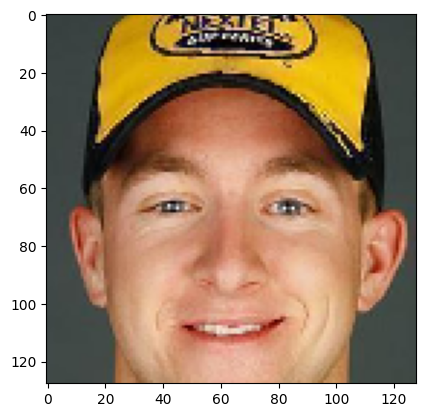

In [75]:
plt.imshow(dd)

In [1]:
###############################################

In [ ]:
import torch
from proGAN import ProGAN
from utils.proGAN_DG import Generator, Discriminator
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import numpy as np
import imageio
import torch
import yaml
from torch.backends import cudnn

from torchvision import transforms
from einops import rearrange
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
from utils.util_function import preprocess_img, get_data_loader
from utils.losses import GANLoss, WganGP
from pathlib import Path

# %load_ext autoreload
# %autoreload 2

gen = Generator(depth = 6)
dis = Discriminator(depth = 6)
pgan = ProGAN(gen,dis)

/mnt/d/labaratory/labo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generator Network: Generator(
  (layers): ModuleList(
    (0): GenInitialBlock(
      (conv_1): EqualizedConvTranspose2d(512, 512, kernel_size=(4, 4), stride=(1, 1))
      (conv_2): EqualizedConv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pixNorm): PixelwiseNorm()
      (lrelu): LeakyReLU(negative_slope=0.2)
    )
    (1-4): 4 x GenGeneralConvBlock(
      (conv_1): EqualizedConv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv_2): EqualizedConv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pixNorm): PixelwiseNorm()
      (lrelu): LeakyReLU(negative_slope=0.2)
    )
  )
  (rgb_converters): ModuleList(
    (0-4): 5 x EqualizedConv2d(512, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)
Discriminator Network: Discriminator(
  (layers): ModuleList(
    (0-3): 4 x DisGeneralConvBlock(
      (conv_1): EqualizedConv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv_2): EqualizedConv2d(512, 512, ke

In [2]:
losses = WganGP()

In [5]:
pgan.train( 
       epochs = [10, 10, 15, 20, 25],
        batch_sizes = [128, 128, 64, 32, 16],
        fade_in_percentages = [30, 30, 30, 30, 30],
        loss_fn = losses,
        batch_repeats = 4,
        gen_learning_rate = 0.003,
        dis_learning_rate = 0.003,
        num_samples = 16,
        start_depth = 2,
        num_workers = 3,
        feedback_factor = 100,
        save_dir=Path("./train"),
        checkpoint_factor = 10
        )

Loaded the dataset with: 162770 images ...
setting up the image saving mechanism
Starting the training process ... 


Currently working on Depth: 2
Current resolution: 4 x 4

Epoch: 1
Elapsed: [0:00:02.659009]  batch: 1  d_loss: -3.431976  g_loss: 9.679581
Elapsed: [0:00:23.415079]  batch: 12  d_loss: -3.102530  g_loss: 3.331806
Elapsed: [0:00:47.449277]  batch: 24  d_loss: -2.351472  g_loss: 2.497321
Elapsed: [0:01:10.280327]  batch: 36  d_loss: -1.749683  g_loss: 1.418303
Elapsed: [0:01:32.986991]  batch: 48  d_loss: -1.008432  g_loss: 0.405436
Elapsed: [0:01:56.098316]  batch: 60  d_loss: -0.915453  g_loss: 0.615121
Elapsed: [0:02:19.873722]  batch: 72  d_loss: -1.072469  g_loss: 1.962300
Elapsed: [0:02:42.501710]  batch: 84  d_loss: -1.006133  g_loss: 1.141475
Elapsed: [0:03:05.482929]  batch: 96  d_loss: -0.718113  g_loss: 0.858337
Elapsed: [0:03:28.477855]  batch: 108  d_loss: -0.197882  g_loss: -0.364498
Elapsed: [0:03:52.584757]  batch: 120  d_loss: -0.719983  g_loss: 0.890911


KeyboardInterrupt: 

In [17]:
tmp = get_data_loader(pgan.dataset,
                      10,
                      3)

In [23]:
dataset = load_dataset('flwrlabs/celeba')

ds = preprocess_img(dataset)

ex = ds["train"][0]
print("train keys:", ex.keys())
print("pixel_values type:", type(ex.get("pixel_values")))
print("image type:", type(ex.get("image")))

train keys: dict_keys(['image', 'celeb_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young', 'pixel_values'])
pixel_values type: <class 'torchvision.tv_tensors._image.Image'>
image type: <class 'PIL.PngImagePlugin.PngImageFile'>


In [13]:
next(tt)

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/mnt/d/labaratory/labo/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/mnt/d/labaratory/labo/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/d/labaratory/image_modeling/GAN/utils/util_function.py", line 65, in collate_pixel_values
    return torch.stack([b["pixel_values"] for b in batch], dim=0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: expected Tensor as element 0 in argument 0, but got Image


In [1]:
from utils.stylegan_DG import Generator, Discriminator
from Style_gan import StyleGAN


/mnt/d/labaratory/labo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cpu"
generator = Generator(
    size=128,
    style_dim=256,
    n_mlp=8,
    channel_multiplier=1,
    blur_kernel=[1, 3, 3, 1],
    lr_mlp=0.01
).to(device)
discriminator = Discriminator(
    size=128,
    blur_kernel=[1, 3, 3, 1],
    channel_multiplier=1
).to(device)


In [3]:
styleGan = StyleGAN(gen=generator,
                     dis=discriminator,
                     device='cpu',
                     use_ema=True,
                     ema_beta=0.999)

In [4]:

styleGan.train(
        epochs=100,
        batch_size=16,      # Lower this if OOM occurs
        gen_lr=0.002,
        dis_lr=0.002,
        num_workers=4,
        save_dir="./stylegan_result",
        checkpoint_factor=10, 
        feedback_factor=100 # Print status every 100 batches
    )


Loaded dataset with 162770 images.
Starting training...


Epoch 1 [0/10173]  D Loss: 1.1389  G Loss: 29.4273
Epoch 1 [100/10173]  D Loss: 0.7613  G Loss: 2.9986


KeyboardInterrupt: 

In [1]:
import os
import numpy as np
import math
from datasets import load_dataset
import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from torchvision import datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.autograd as autograd
from PIL import Image
import io

import matplotlib.pyplot as plt

/mnt/d/labaratory/labo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data = load_dataset('huggan/facades')

Repo card metadata block was not found. Setting CardData to empty.


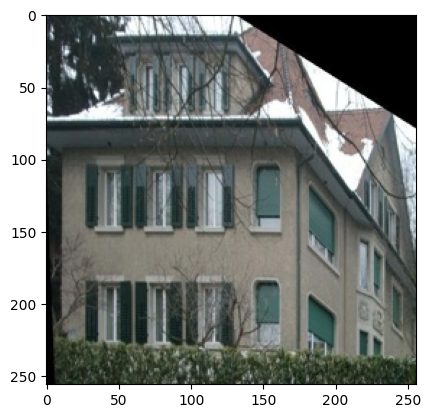

In [ ]:
img_bytes = data['train'][0]['imageB']['bytes']

img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

plt.imshow(img)

In [2]:
start_epoch, end_epochs = 0, 200
batch_size = 1
learning_rate = 0.002
b1, b2 = 0.5, 0.999
img_h, img_w = 256, 256
sample_interval = 500

In [ ]:
def preprocess_img(dataset, size=256):
    transform_ = transforms.Compose(
        [transforms.Resize((img_h, img_w), Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


    def transform_fn(ex):
        # Handle grayscale images by converting to RGB if needed
        # (CelebA is RGB but robust code helps)
        # However, T.ToImage() handles PIL.

        ex_a = list(map(lambda x : Image.open(io.BytesIO(x['bytes'])).convert('RGB'), ex["imageA"]))
        ex_b = list(map(lambda x : Image.open(io.BytesIO(x['bytes'])).convert('RGB'), ex["imageA"]))
        ex["pixel_image_A"] = [transform_(i) for i in ex_a]
        ex["pixel_image_B"] = [transform_(i) for i in ex_b]
        return ex

    for split in dataset.keys():
        dataset[split].set_transform(transform_fn)

    return dataset



In [6]:
ttt = preprocess_img(data)

In [65]:
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)
        
class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_size),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip_input):
        x = self.model(x)

        x = torch.cat([x, skip_input], 1)
        return x

In [66]:
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GeneratorUNet, self).__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1,0,1,0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6 ,d1)
        return self.final(u7)




In [ ]:
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super(Discriminator, self).__init__()
        def discriminator_block(in_channels, out_channels, normalize=True):
            layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1,0,1,0)),
            nn.Conv2d(512, 1, 4, 1, padding = 1,bias = False)
        )

    def forward(self, img, img2):
        img_input = torch.cat((img, img2),1)
        return self.model(img_input)

In [85]:
criterion_GAN = torch.nn.MSELoss()
criterion_pixelwise = torch.nn.L1Loss()

lambda_pixel = 100
lr = 0.0002

patch = (1, img_h//2 ** 2, img_w//2 ** 4)

generator = GeneratorUNet(3,3)
discriminator = Discriminator(3)

optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

transform_ = transforms.Compose(
    [transforms.Resize((img_h, img_w), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


  

In [50]:
ttt["train"][0]['pixel_image_A']

tensor([[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         ...,
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

        [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         ...,
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

        [[ 0.7412,  0.7412,  0.7412,  ...,  0.7412,  0.7412,  0.7412],
         [ 0.7412,  0.7412,  0.7412,  ...,  0

In [69]:
def collate_pixel_values(batch):
    # batch: List[dict], 각 dict에 'pixel_values'가 있음
    return {'a' : torch.stack([b["pixel_image_A"] for b in batch], dim=0), 'b' : torch.stack([b["pixel_image_B"] for b in batch], dim=0)}

def get_data_loader(
    dataset: Dataset, batch_size: int, num_workers: int = 3
) -> DataLoader:
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True,
        collate_fn=collate_pixel_values
    )

data_loader = get_data_loader(ttt['train'], batch_size=16)

In [62]:
tmp = next(iter(data_loader))

In [87]:
device = 'cpu'
for epoch in range(100):
    for i, batch in enumerate(data_loader):
        real_a = batch['a'].to(device)
        real_b = batch['b'].to(device)
        
        valid = torch.ones(real_a.size(0), 1).to(device)
        fake = torch.zeros(real_a.size(0), 1).to(device)
        
        optimizer_G.zero_grad()

        fake_b = generator(real_a)
        pred_fake = discriminator(fake_b, real_a)
        loss_GAN = criterion_GAN(pred_fake, valid)
        loss_pixel = criterion_pixelwise(fake_b, real_b)

        loss_G = loss_GAN + lambda_pixel * loss_pixel
        loss_G.backward()
        optimizer_G.step()

        optimizer_D.zero_grad()
        
        pred_real = discriminator(real_b, real_a)
        loss_real = criterion_GAN(pred_real, valid)
        
        pred_fake = discriminator(fake_b.detach(), real_a)
        loss_fake = criterion_GAN(pred_fake, fake)
        
        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        batches_done = epoch * len(data_loader) + i
    print(epoch)

        

/mnt/d/labaratory/labo/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 1, 16, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0
1


KeyboardInterrupt: 

In [81]:
pred_fake.shape

torch.Size([16, 1, 14, 14])

In [77]:
real_a.shape

torch.Size([16, 3, 256, 256])

In [ ]:
def collate_pixel_values(batch):
    # batch: List[dict], 각 dict에 'pixel_values'가 있음
    return torch.stack([b["pixel_values"] for b in batch], dim=0)

def get_data_loader(
    dataset: Dataset, batch_size: int, num_workers: int = 3
) -> DataLoader:
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True,
        collate_fn=collate_pixel_values
    )